In [19]:
from tensorflow import keras
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import SimpleRNN
from keras.datasets import imdb
from keras import initializers
import matplotlib.pyplot as plt

In [2]:
max_features = 20000
maxlen = 30
batch_size = 32

In [3]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

25000 train sequences
25000 test sequences


In [6]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)

x_train shape:  (25000, 30)
x_test shape:  (25000, 30)


In [7]:
x_train[123,:]

array([  219,   141,    35,   221,   956,    54,    13,    16,    11,
        2714,    61,   322,   423,    12,    38,    76,    59,  1803,
          72,     8, 10508,    23,     5,   967,    12,    38,    85,
          62,   358,    99])

In [12]:
rnn_hidden_dim = 5
word_embedding_dim = 50
model_rnn= Sequential()
model_rnn.add(Embedding(max_features, word_embedding_dim))
model_rnn.add(SimpleRNN(
    rnn_hidden_dim,
    kernel_initializer=initializers.RandomNormal(stddev=0.001),
    recurrent_initializer=initializers.Identity(gain=1.0),
    activation='relu',
    input_shape = x_train.shape[1:]
))

model_rnn.add(Dense(1, activation='sigmoid'))

c:\Users\one\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=.0001)

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer=rmsprop,
    metrics=['accuracy'])

In [17]:
history = model_rnn.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=10,
    validation_data=(x_test, y_test))

Epoch 1/10


782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8429 - loss: 0.3578 - val_accuracy: 0.7893 - val_loss: 0.4492
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8474 - loss: 0.3520 - val_accuracy: 0.7890 - val_loss: 0.4504
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8502 - loss: 0.3467 - val_accuracy: 0.7901 - val_loss: 0.4500
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8528 - loss: 0.3415 - val_accuracy: 0.7904 - val_loss: 0.4519
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8559 - loss: 0.3372 - val_accuracy: 0.7905 - val_loss: 0.4503
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8604 - loss: 0.3333 - val_accuracy: 0.7910 - val_loss: 0.4519
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8595 - loss: 0.3294 - val_accuracy: 0.7908 - val_loss: 0.4568
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8639 - loss: 0.3262 - val_accuracy: 0.7911 - val

In [16]:
score, acc = model_rnn.evaluate(x_test, y_test,batch_size=batch_size)
print('Test score: ', score)
print('Test accuracy: ', acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7878 - loss: 0.4495
Test score:  0.4494988024234772
Test accuracy:  0.7878000140190125


In [ ]:
loss = history.history['loss']
acc = history.history['accuracy']

val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']

In [28]:
def display_metrics(history, save = False, save_path = 'results.png'):
    n = len(history.history['loss'])

    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(range(n), (history.history['loss']), 'r', label='Train Loss')
    ax.plot(range(n), history.history['val_loss'], 'b', label='Validation Loss')
    ax.legend(loc='lower right')
    ax.set_title('Loss over iterations')
    
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(range(n), (history.history['accuracy']), 'r', label='Train Acc')
    ax.plot(range(n), (history.history['val_accuracy']), 'b', label='Train Acc')

    ax.legend(loc='lower right')
    ax.set_title('Accuracy over iterations')

    if save:
        plt.savefig(save_path)

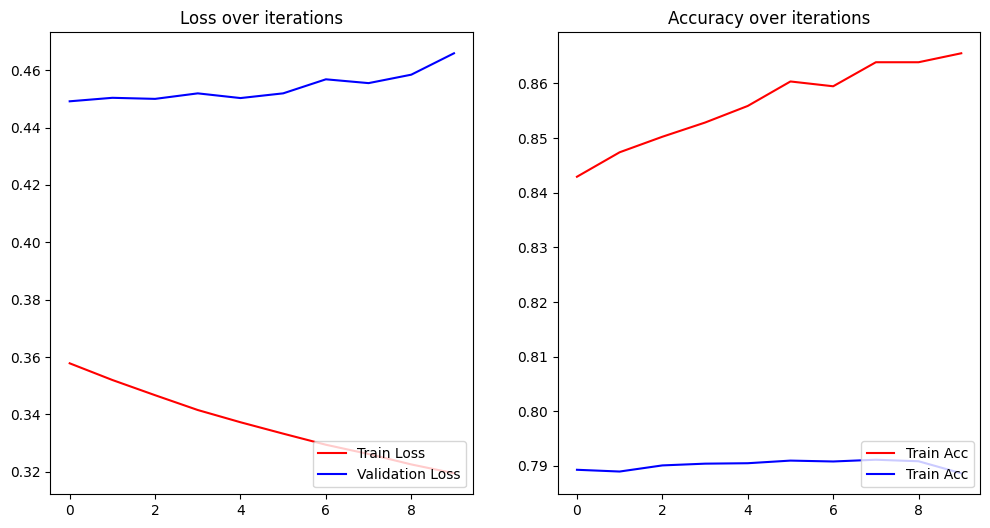

In [29]:
display_metrics(history, save=True, save_path='./results/results1.png')

In [31]:
model_rnn.save('./models/classifier.keras')